<a href="https://colab.research.google.com/github/Muqqadas30/fsdl-my-labs/blob/main/lab08/lab08_monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gradio pandas seaborn --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from PIL import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import csv
import os
from datetime import datetime

In [2]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

train_raw = datasets.FashionMNIST(root="./data", train=True, download=True)
test_raw = datasets.FashionMNIST(root="./data", train=False, download=True)

x_train = train_raw.data.float().unsqueeze(1) / 255.0
y_train = train_raw.targets

model = SimpleCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(3):
    for i in range(0, len(x_train), 64):
        xb = x_train[i:i+64]
        yb = y_train[i:i+64]
        optimizer.zero_grad()
        loss = F.cross_entropy(model(xb), yb)
        loss.backward()
        optimizer.step()

model.eval()

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.5MB/s]


SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [3]:
LOG_FILE = "prediction_logs.csv"

def log_prediction(image_mean, predicted_class, confidence, environment="prod"):
    file_exists = os.path.exists(LOG_FILE)

    with open(LOG_FILE, "a", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(["timestamp", "image_mean_brightness", "predicted_class", "confidence", "environment"])
        writer.writerow([datetime.now().isoformat(), image_mean, predicted_class, confidence, environment])


def predict_and_log(image_tensor, environment="prod"):
    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0))
        probs = F.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()

    image_mean = image_tensor.mean().item()
    log_prediction(image_mean, class_names[pred_idx], confidence, environment)

    return class_names[pred_idx], confidence

In [4]:
x_test = test_raw.data.float().unsqueeze(1) / 255.0

for i in range(200):
    predict_and_log(x_test[i], environment="test")

print("200 test predictions logged as baseline")

200 test predictions logged as baseline


In [5]:
for i in range(200, 350):
    predict_and_log(x_test[i], environment="prod")

for i in range(350, 400):
    inverted_image = 1.0 - x_test[i]
    predict_and_log(inverted_image, environment="prod")

print("Production predictions logged (including some inverted/shifted images)")

Production predictions logged (including some inverted/shifted images)


In [6]:
df = pd.read_csv(LOG_FILE)
print("Total logged predictions:", len(df))
print(df.head())
print("\nEnvironment counts:")
print(df["environment"].value_counts())

Total logged predictions: 400
                    timestamp  image_mean_brightness predicted_class  \
0  2026-07-19T07:24:31.679520               0.167347      Ankle boot   
1  2026-07-19T07:24:31.680692               0.505172        Pullover   
2  2026-07-19T07:24:31.681503               0.257703         Trouser   
3  2026-07-19T07:24:31.682192               0.176956         Trouser   
4  2026-07-19T07:24:31.682832               0.313400           Shirt   

   confidence environment  
0    0.736051        test  
1    0.953229        test  
2    0.999923        test  
3    0.999956        test  
4    0.800290        test  

Environment counts:
environment
test    200
prod    200
Name: count, dtype: int64


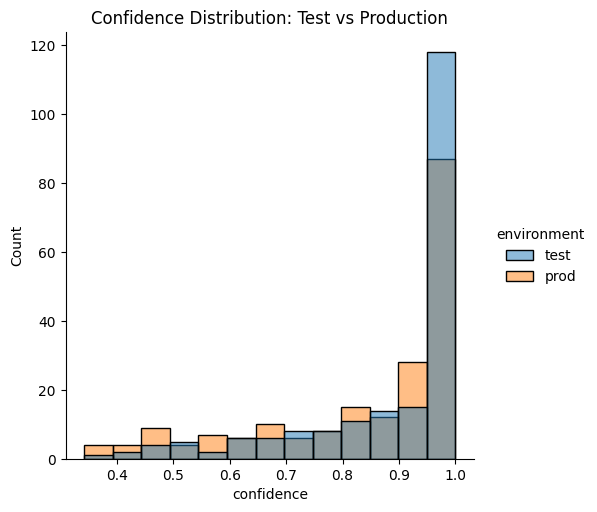

In [7]:
sns.displot(
    data=df,
    x="confidence",
    hue="environment"
)
plt.title("Confidence Distribution: Test vs Production")
plt.show()

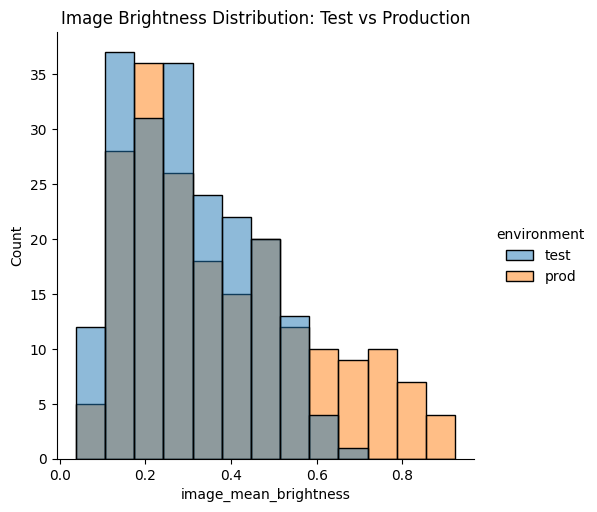

In [8]:
sns.displot(
    data=df,
    x="image_mean_brightness",
    hue="environment"
)
plt.title("Image Brightness Distribution: Test vs Production")
plt.show()

In [9]:
low_confidence = df[(df["environment"] == "prod") & (df["confidence"] < 0.5)]
print(f"Low confidence predictions in production: {len(low_confidence)}")
print(low_confidence.head(10))

Low confidence predictions in production: 17
                      timestamp  image_mean_brightness predicted_class  \
222  2026-07-19T07:24:45.431443               0.177006           Shirt   
244  2026-07-19T07:24:45.444178               0.438335        Pullover   
255  2026-07-19T07:24:45.450626               0.478431           Shirt   
273  2026-07-19T07:24:45.460981               0.391687        Pullover   
286  2026-07-19T07:24:45.468424               0.441632           Shirt   
289  2026-07-19T07:24:45.470139               0.259414            Coat   
332  2026-07-19T07:24:45.495960               0.444868           Dress   
337  2026-07-19T07:24:45.498929               0.559009           Shirt   
353  2026-07-19T07:24:45.508752               0.553061           Shirt   
357  2026-07-19T07:24:45.511157               0.595388     T-shirt/top   

     confidence environment  
222    0.397538        prod  
244    0.446328        prod  
255    0.485128        prod  
273    0.451922     

In [10]:
stats = df.groupby("environment")[["confidence", "image_mean_brightness"]].describe()
print(stats)

            confidence                                                    \
                 count      mean       std       min       25%       50%   
environment                                                                
prod             200.0  0.848997  0.182671  0.342434  0.753308  0.935670   
test             200.0  0.891608  0.153923  0.390989  0.827646  0.972066   

                                image_mean_brightness                      \
                  75%       max                 count      mean       std   
environment                                                                 
prod         0.994789  0.999974                 200.0  0.384934  0.214078   
test         0.998355  0.999974                 200.0  0.295008  0.143082   

                                                               
                  min       25%       50%       75%       max  
environment                                                    
prod         0.055337  0.210324  0.321083

In [11]:
import gradio as gr

def gradio_predict(image):
    if image is None:
        return "Koi image upload nahi hui"

    img = Image.fromarray(image).convert("L").resize((28, 28))
    img_array = np.array(img).astype(np.float32) / 255.0
    img_tensor = torch.tensor(img_array).unsqueeze(0)

    pred_class, confidence = predict_and_log(img_tensor, environment="prod")
    return f"{pred_class} ({confidence:.1%} confident)"


frontend = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="numpy", image_mode="L"),
    outputs=gr.Textbox(label="Prediction"),
    title="Fashion-MNIST Classifier (With Monitoring)",
    description="Prediction ke sath, har request automatically CSV mein log ho rahi hai monitoring ke liye.",
    flagging_mode="manual"
)

frontend.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fea1d884aa9fef87c3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [12]:
if os.path.exists("flagged"):
    print(os.listdir("flagged"))
    flagged_log = Path("flagged") / "log.csv"
    if flagged_log.exists():
        flagged_df = pd.read_csv(flagged_log)
        print(flagged_df)

In [13]:
frontend.close()

Closing server running on port: 7860
